# ChemiAI — предсказание IC50, CC50 и SI

**Автор:** 5 - 5_ИИшница
**Дата:** май 2026

**Аннотация:**
Разработка лекарств включает длительный цикл синтеза и биологического тестирования.
Машинное обучение позволяет оценивать активность молекул до лабораторных экспериментов.
По 192 дескрипторам из библиотеки **RDKit** строятся модели против вируса гриппа.
Для каждого соединения предсказываются **IC50**, **CC50** и **SI** (selectivity index, индекс селективности).
Метрика — средний **RMSE** (root mean squared error, среднеквадратичная ошибка) по трём таргетам (меньше — лучше).
Финальный ансамбль: **CatBoost**, **LightGBM**, база **ChEMBL** и два признака **k ближайших соседей (kNN)** по IC50.
Локальная оценка **OOF** (out-of-fold, предсказание на отложенном фолде) ≈ 525 RMSE.
Файл `submission.csv` формируется при полном прогоне ноутбука.

**Оглавление:**
1. [Введение](#1-введение-и-контекст)
2. [Данные](#2-загрузка-и-понимание-данных)
3. [Подготовка](#3-подготовка-данных)
4. [Моделирование](#4-анализ-и-моделирование)
5. [Интерпретация](#5-интерпретация-и-обсуждение)
6. [Заключение](#6-заключение-и-дальнейшие-шаги)
7. [Приложение — код](#7-приложение--код-пайплайна)
8. [Воспроизведение](#8-воспроизведение-результатов)


In [125]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field
from pathlib import Path

import catboost
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
DATA_DIR = ROOT / "data"
if not (DATA_DIR / "train.csv").is_file():
    raise FileNotFoundError(
        "Не найден data/train.csv. Запустите ноутбук из корня репозитория "
        "(рядом solution.ipynb и папка data/)."
    )
RANDOM_STATE = 42
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
ID_COL = "index"
OUTPUT_PATH = ROOT / "submission.csv"

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("catboost:", catboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("RANDOM_STATE:", RANDOM_STATE)


Python: 3.13.5
pandas: 3.0.3
numpy: 1.26.4
scikit-learn: 1.8.0
catboost: 1.2.10
lightgbm: 4.6.0
RANDOM_STATE: 42


## 1. Введение и контекст


Разработка противовирусных препаратов требует оценки **эффективности** и **токсичности** каждого соединения.
Химики предоставили молекулярные дескрипторы и результаты тестов in vitro против вируса гриппа.
По строке **SMILES** (упрощённая запись структуры) через RDKit получают числовые признаки молекулы.

**Цель работы:** построить воспроизводимый ансамбль регрессии **отдельно по каждому таргету**, минимизирующий средний RMSE на **кросс-валидации (CV, cross-validation)**.

**IC50 (mM)** — концентрация, при которой подавляется 50% вирусной активности.
**CC50 (mM)** — концентрация, при которой токсичны 50% клеток.
**SI** — индекс селективности; связан с IC50 и CC50, но предсказывается отдельной переменной.

**Задачи:**
1. Отобрать информативные признаки из 214 RDKit-дескрипторов (остаётся 192 после удаления констант).
2. Подключить внешнюю базу ChEMBL с учётом смещения распределений.
3. Спроектировать ансамбль с отдельными ветками IC50 / CC50 / SI и пост-коррекцией SI.
4. Зафиксировать конфиг `BEST_CFG` и воспроизводимость (**seed** — начальное значение генератора, 5 фолдов CV).

**Метрика** (средний RMSE):

$$\text{score} = \frac{\text{RMSE(IC50)} + \text{RMSE(CC50)} + \text{RMSE(SI)}}{3}$$

**Ограничения:** малый train (n=751), смещение ChEMBL vs основной датасет, трансдуктивные признаки (**PCA** — метод главных компонент, principal component analysis — и kNN на train∪test).

## 2. Загрузка и понимание данных


Датасет описывает **1000 химических соединений** числовыми молекулярными дескрипторами (RDKit, без SMILES в таблице).
Файлы лежат в `data/` рядом с ноутбуком (относительные пути).

**Разделение выборок:**
- `train.csv` — **751** объект с известными IC50, CC50 и SI.
- `test.csv` — **250** объектов для предсказания (таргеты скрыты).
- `sample_submission.csv` — формат итогового файла: `index`, `IC50`, `CC50`, `SI`.

**Внешние данные (ChEMBL, похожие активные молекулы):**
- `external_chembl_ic50_sim_potent.csv` — IC50 для kNN-признаков и объединения с LightGBM.
- `external_chembl_cc50_proxy_potent.csv` — прокси CC50 для калиброванного kNN.

**Признаки:** исходно **214** числовых дескрипторов на молекулу; после удаления 18 константных на train остаётся **192** активных колонки.
Группы признаков:
1. **Общие свойства** — `MolWt`, `MolLogP`, `TPSA`, `LabuteASA`, …
2. **Зарядовые** — `MaxPartialCharge`, `PEOE_VSA*`, …
3. **Топологические** — `Chi*`, `Kappa*`, `BertzCT`, `FractionCSP3`, …
4. **Поверхностные VSA** — `SMR_VSA*`, `SlogP_VSA*`, `EState_VSA*`, …
5. **Функциональные группы** — бинарные `fr_*` (ester, amide, halogen, …).
6. **Специфические** — `EState` индексы, `BCUT2D_*`, `FpDensityMorgan*`.

Исполняемые ячейки загрузки и EDA — в [§8.1–§8.2](#81-загрузка-csv).

## 3. Подготовка данных


Отбираем **192** RDKit-признака из 214 (без `index` и таргетов).
Удаляем **18 константных** колонок на train.
Внешние CSV выравниваем функцией `align_to_train_features`.
Добавляем вычисленные признаки: 4 отношения, 2 разности (IC50), kNN из ChEMBL (калиброванный и сырой).
Проверка пропусков и констант — [§8.3](#83-проверка-признаков).

## 4. Анализ и моделирование


Финальная модель — **ансамбль из нескольких регрессоров**, у каждого таргета (IC50, CC50, SI) своя логика смешивания предсказаний.

**Базовый блок (общий для IC50, CC50 и SI).**
Молекулы делятся на 4 кластера (KMeans по RDKit-дескрипторам).
На кластерных признаках обучаются градиентный бустинг (HistGradientBoosting) и CatBoost.
Для **CC50** добавлен **трансдуктивный kNN**: PCA строится на объединении обучающей и тестовой выборок, затем ищутся k ближайших соседей — так модель учитывает структуру тестовых молекул.

**Предсказание IC50 (концентрация, подавляющая вирус).**
1. **Разностные признаки** — разница между дескрипторами гетероциклов, гибкости и размера молекулы.
2. **CatBoost на всех 192+ признаках** — вклад в итоговое IC50 **20%** (остальное — из базового блока и других моделей).
3. **LightGBM** — главная модель для IC50 (**59%** вклада).
   В каждом фолде к обучающим строкам добавляются похожие молекулы из базы **ChEMBL** (вес этих строк **15%**, чтобы не «перетянуть» модель на чужое распределение).
4. **Два kNN-признака по ChEMBL** (число соседей **k=4**):
   — *калиброванный*: медиана IC50 соседей, шкала приведена к train через квантильное отображение;
   — *сырой*: медиана без калибровки (дополнительный сигнал).

**Предсказание CC50 (токсичность для клеток).**
К базовому трансдуктивному kNN добавлен **kNN-признак по прокси-CC50 из ChEMBL** (**k=6**, с калибровкой шкалы на train).

**Предсказание SI (индекс селективности).**
Сначала SI предсказывается регрессией в базовом блоке.
Затем результат **смешивается** с физическим отношением CC50/IC50: **30%** — модель, **70%** — отношение CC50/IC50 (параметр α=0.30).

**Проверка качества и воспроизводимость.**
Оценка на train — **5-fold CV**: каждый объект один раз попадает в validation, получаем OOF-предсказания.
Предсказания для test **усредняются** по двум запускам с разными seed (**42** и **7**).
**Метрика:** среднее RMSE по IC50, CC50 и SI.

Обучение и формирование файла ответов — [§8.4–§8.5](#84-обучение-и-oof).

### 4.1 Закрытые ветки (не вошли в финал)


Подробная хронология всех проведённых экспериментов — в [EXPERIMENTS.md](EXPERIMENTS.md).


В ходе **35+ фаз** экспериментов перебрали десятки гипотез.
Ниже — ветки, которые **не вошли в финал**: ухудшение метрики, расхождение OOF и отложенной выборки или насыщение эффекта.

#### SI (индекс селективности)

**Жёсткая формула SI = CC50 / IC50** — метрика ~360 RMSE: игнорируется шум измерений и вклад других таргетов.

**Meta-смешивание SI через Ridge/Huber** (Phase V, `si_meta_ridge`) — худший провал серии: на OOF казалось −8.6 RMSE, на test **+44 RMSE**.
Обучаемые meta-модели для SI **закрыты навсегда**; в финале только мягкое смешивание предсказания регрессии с физическим отношением CC50/IC50 (α=0.30).

**CatBoost и transductive kNN для SI** (Phase D, F: huber, mordred-SI, `si_trans_k5`) — регресс +5…+8 RMSE относительно лучшего стека.
На OOF улучшения казались убедительными, на отложенной выборке — нет → **все отдельные SI-ветки закрыты**.

**α=0.38** стабильно хуже зафиксированных **α=0.32** и **α=0.30**.

#### IC50

**Стекинг Ridge по OOF-предсказаниям** — ~317 RMSE (хуже простого baseline ~306).

**Предсказание в шкале pIC50, isotonic-калибровка** — не дали устойчивого выигрыша.

**Признаки fe_v2, Ro5, отдельные mordred-модели** (Phase P) — слабее structural-ансамбля Phase H.

**LightGBM в structural-ветке, попарные взаимодействия** (Phase L2) — регресс ~+0.7 RMSE.

**Только kNN-признак без объединения ChEMBL в функции потерь** (`knn_cal_only`, Phase AC) — одного признака мало; объединение с весом 0.15 обязательно.

**Pretrain / ext_cal на метках ChEMBL** (Phase AB) — смещение меток, +2…+3 RMSE.

**Альтернативные табличные модели** (Phase C/C2) — OOF-сетка не переносилась на test → ветка закрыта.

#### Внешние данные и смешивание

**Полное объединение ChEMBL 2700+ строк** (w=0.1, Phase X) — смещение распределений, ~271 RMSE.

**Объединение DDH, sim-фильтры n100 / n180 / n220** — хуже библиотеки **похожих активных** молекул (Phase X3, Y).

**ext_weight > 0.15** — стабильный регресс (Phase Y: w=0.155, w=0.160).

**Усреднение по 3 seed** (Phase AA) — нестабильно, закрыто; в финале 2 seed (42, 7).

**Жёсткий порог pChEMBL ≥5.0 / ≥6.0** (`potent50`, `potent60`) — хуже текущего sim-фильтра активных.

#### CC50

**cc50_trans_k=4** — ~270.7 RMSE, хуже k=3.

**blend_w > 0.70** (Phase R: 0.72–0.78) — микро-сетка не дала улучшения.

**Трансдуктивные physchem-признаки** (Phase V) — OOF +5…+16, бесполезно.

**cc50_dual_fe, cc50_shape, routed_dual** (Phase W) — типичное расхождение: OOF −0.8, test **+1.1…+1.2 RMSE**.

**CC50 kNN с n200 proxy, k=7/k=8, dual/shape/trans_k4** (Phase AE) — хуже связки **k=6 + активный proxy**; отдельные dual/shape закрыты.

#### Прочее

**GNN / ChemBERTa** — в CSV нет SMILES для inference.

**Микро-тюнинг full_cb_w ≠ 0.20** (Phase M) — регресс.

**Мультитarget CatBoost minimal, полный seed-ensemble** — без выигрыша.

---

**Принято в финал:** kNN IC50 k=4 (калиброванный + сырой) + CC50 kNN k=6 + ChEMBL + конфиг `BEST_CFG`.

## 5. Интерпретация и обсуждение


Ожидаемые наблюдения (числа — в [§8.4](#84-обучение-и-oof)):
**OOF ≈ 525 RMSE** — оценка на 5 фолдах train.
Трансдуктивные признаки и внешняя база **завышают** OOF относительно «чистой» отложенной выборки.
На OOF больше всего ошибка по **SI**, затем **CC50**; главный резерв — ветка **IC50**.
Наибольший вклад: разностные признаки, объединение ChEMBL (вес 0.15), два kNN-признака по IC50.
Итоговый файл ответов — [§8.5](#85-формирование-сабмита).

## 6. Заключение и дальнейшие шаги


Финальный пайплайн (kNN k=4, CC50 k=6, двойной kNN по IC50) зафиксирован в `BEST_CFG`.
Главный выигрыш — разностные признаки IC50, ChEMBL и два kNN-признака.
Воспроизведение: `pip install -r requirements.txt` → полный прогон ноутбука (нужен **rdkit**).

**Ограничения:**
Малый train (751) — высокая дисперсия OOF и риск переобучения на ChEMBL.
Смещение распределений ChEMBL — внешнюю выборку добавляем только с малым весом (0.15).
Трансдуктивные признаки — OOF не отражает качество на отложенном test.
SI связан с IC50/CC50; жёсткие ratio-модели ухудшают метрику.
Часть гиперпараметров подбиралась итеративно; OOF для IC50 систематически завышен.

**Дальнейшие шаги:**
Микро-подбор `lgb_w`, `ext_weight`, `knn_k` только там, где OOF стабилен.
Другие фильтры ChEMBL (Tanimoto ≥ 0.6) без роста смещения распределений.
Отдельная калибровка SI без meta-Ridge (ветка дала +44 RMSE).
Убрать трансдуктивные компоненты для более честного локального мониторинга.

## 7. Приложение — код пайплайна


Минимальный код для конфигурации `BEST_CFG` (kNN k=4, CC50 k=6, двойной kNN по IC50).
Отдельных `.py`-модулей нет — только ячейки ноутбука.
Перед прогоном §8 выполните все ячейки этого раздела.

### A.1 RDKit — выравнивание признаков


**Константы** (`CONSTANT_COLUMNS`)

Список **18 RDKit-колонок**, константных на train (nunique ≤ 1).
Не входят в 192 активных признаков; удаляются в `load_data` и при выравнивании ChEMBL.


In [126]:
CONSTANT_COLUMNS: tuple[str, ...] = (
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_N_O",
    "fr_SH",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_dihydropyridine",
    "fr_isocyan",
    "fr_isothiocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_phos_acid",
    "fr_phos_ester",
    "fr_prisulfonamd",
    "fr_thiocyan",
)

**`active_feature_columns`**

Отбирает **192 активных** RDKit-дескрипторов из полного списка колонок.
Исключает 18 колонок из `CONSTANT_COLUMNS`, которые на train не меняются.
Используется при загрузке внешних CSV, чтобы совпасть с train/test.


In [127]:
def active_feature_columns(all_cols: list[str]) -> list[str]:
    """192 активных desc-колонок (без 18 константных на train)."""
    const = set(CONSTANT_COLUMNS)
    return [c for c in all_cols if c not in const]

**`align_to_train_features`**

Приводит внешний DataFrame к **тому же набору и порядку колонок**, что и train.
Проверяет наличие всех нужных дескрипторов; при отсутствии — `ValueError`.
Возвращает матрицу признаков `float` без `index` и таргетов.


In [128]:
def align_to_train_features(df: pd.DataFrame, train_cols: list[str] | None = None) -> pd.DataFrame:
    """Выравнивает external CSV под колонки train."""
    active = train_cols or active_feature_columns(list(df.columns))
    missing = [c for c in active if c not in df.columns]
    if missing:
        raise ValueError(f"Не хватает колонок: {missing[:5]}… ({len(missing)} всего)")
    return df[active].astype(float)

### A.2 Базовый пайплайн и метрики


**Константы** (`RANDOM_STATE`, `N_SPLITS`, `N_CLUSTERS`, `N_JOBS`, `CATBOOST_THREADS`, `TARGET_COLS`, `SUBMISSION_COLS`, `ID_COL`, `DATA_DIR`, `SIZE_FEATURE_NAMES` …)

Глобальные **константы пайплайна**: seed, число фолдов (`N_SPLITS=5`), кластеров (`N_CLUSTERS=4`).
`TARGET_COLS`, `SUBMISSION_COLS`, `DATA_DIR` — имена колонок и пути.
`_FOLD_CACHE` — кэш моделей фолда для ускорения повторных вызовов.


In [129]:
RANDOM_STATE = 42
N_SPLITS = 5
N_CLUSTERS = 4
N_JOBS = -1
CATBOOST_THREADS = -1
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
SUBMISSION_COLS = ["IC50", "CC50", "SI"]
ID_COL = "index"
DATA_DIR = Path("data")

SIZE_FEATURE_NAMES = [
    "LabuteASA", "MolMR", "Chi0", "MolWt", "ExactMolWt",
    "Kappa1", "HeavyAtomCount", "Kappa2",
]
EXTENDED_IC50_FEATURES = SIZE_FEATURE_NAMES + [
    "Chi1", "Chi2", "Chi3", "Kappa3", "HallKierAlpha", "BertzCT",
    "NumRotatableBonds", "FractionCSP3", "TPSA", "MolLogP",
]
FR_PREFIX = "fr_"

# Кэш дорогих fold-компонентов между вызовами fit_oof (один процесс).
_FOLD_CACHE: dict[tuple, object] = {}

**`clear_fold_cache`**

Очищает глобальный `_FOLD_CACHE` — кэш тяжёлых компонентов фолда (кластеризация, трансдуктив, CatBoost).
Вызывается перед каждым новым seed и перед `predict_test`, чтобы не смешивать фолды между прогонами.


In [130]:
def clear_fold_cache() -> None:
    _FOLD_CACHE.clear()

**`competition_score`**

Считает **целевую метрику**: средний RMSE по трём таргетам (IC50, CC50, SI).
На входе `y_true`, `y_pred` формы `(n, 3)` в шкале mM.
Используется для OOF-оценки на кросс-валидации.


In [131]:
def competition_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    rmses = [
        np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        for i in range(3)
    ]
    return float(np.mean(rmses))

**`per_target_rmse`**

Возвращает список из **трёх RMSE** — отдельно IC50, CC50, SI.
Показывает, какой таргет доминирует в ошибке (на OOF обычно SI и CC50).


In [132]:
def per_target_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> list[float]:
    return [
        float(np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])))
        for i in range(3)
    ]

**`load_data`**

Загружает `data/train.csv` и `data/test.csv`.
Формирует `X_train`, `X_test` (192 признака), `y_train` формы `(751, 3)`.
Удаляет константные колонки на train; проверяет `assert shape[1] == 192`.


In [133]:
def load_data() -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray, list[str]]:
    train = pd.read_csv(DATA_DIR / "train.csv")
    test = pd.read_csv(DATA_DIR / "test.csv")
    feature_cols = [c for c in train.columns if c not in [ID_COL, *TARGET_COLS]]
    X_train = train[feature_cols].copy()
    y_train = train[TARGET_COLS].values.astype(float)
    X_test = test[feature_cols].copy()

    const_cols = [c for c in X_train.columns if X_train[c].nunique(dropna=False) <= 1]
    X_train = X_train.drop(columns=const_cols)
    X_test = X_test.drop(columns=const_cols)
    assert X_train.shape[1] == 192, X_train.shape[1]
    return X_train, X_test, y_train, list(X_train.columns)

**`build_clustering_features`**

Строит признаки для **фолда с кластеризацией**: медианное impute → StandardScaler → KMeans (`n_clusters=4`).
К one-hot кластеров добавляются imputed-дескрипторы; обучение только на `X_fit`, применение на valid/test.
Трансдуктивный kMeans здесь **не** используется — только внутри train-фолда.


In [134]:
def build_clustering_features(
    X_fit: pd.DataFrame,
    X_apply: pd.DataFrame,
    n_clusters: int = N_CLUSTERS,
    random_state: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray]:
    imputer = SimpleImputer(strategy="median")
    X_fit_imp = imputer.fit_transform(X_fit)
    X_apply_imp = imputer.transform(X_apply)

    scaler = StandardScaler()
    X_fit_scaled = scaler.fit_transform(X_fit_imp)
    X_apply_scaled = scaler.transform(X_apply_imp)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init="auto",
    )
    fit_clusters = kmeans.fit_predict(X_fit_scaled)
    apply_clusters = kmeans.predict(X_apply_scaled)

    X_fit_aug = np.hstack([X_fit_imp, np.eye(n_clusters)[fit_clusters]])
    X_apply_aug = np.hstack([X_apply_imp, np.eye(n_clusters)[apply_clusters]])
    return X_fit_aug, X_apply_aug

**`make_transductive_pca_features`**

**Трансдуктивный PCA** на объединении train-фолда + test (751+250 строк).
Impute → scale → PCA (`n_components` ≤ 20) fit на train∪test, transform на fit/valid/test.
Нужен для kNN-ветки CC50: test видит структуру тестовых молекул.


In [135]:
def make_transductive_pca_features(
    X_fit_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test_full: pd.DataFrame,
    n_components: int = 20,
    random_state: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    fit_frame = pd.concat([X_fit_train, X_test_full], axis=0)
    imputer = SimpleImputer(strategy="median")
    fit_imputed = imputer.fit_transform(fit_frame)
    scaler = StandardScaler()
    fit_scaled = scaler.fit_transform(fit_imputed)
    n_comp = min(n_components, fit_scaled.shape[0], fit_scaled.shape[1])
    pca = PCA(n_components=n_comp, random_state=random_state)
    pca.fit(fit_scaled)

    def transform(frame: pd.DataFrame) -> np.ndarray:
        return pca.transform(scaler.transform(imputer.transform(frame)))

    return transform(X_fit_train), transform(X_valid), transform(X_test_full)

**`enforce_si_invariant`**

Постобработка предсказаний: смешивает SI от модели с физическим отношением **CC50/IC50**.
`SI_new = α·SI_ml + (1−α)·(CC50/IC50)`, затем clip ≥ 0.
При BEST_CFG `α = 0.30` — баланс регрессии и химической связи таргетов.


In [136]:
def enforce_si_invariant(
    predictions: np.ndarray,
    alpha: float = 0.35,
    eps: float = 1e-3,
) -> np.ndarray:
    result = predictions.copy()
    ic50_safe = np.clip(result[:, 0], eps, None)
    si_ratio = result[:, 1] / ic50_safe
    result[:, 2] = alpha * result[:, 2] + (1.0 - alpha) * si_ratio
    return np.clip(result, 0, None)

**`_catboost`**

Фабрика `CatBoostRegressor` с фиксированными гиперпараметрами:
depth=6, lr=0.03, iterations=500, `thread_count=-1`.
Принимает переопределения через `**kwargs` (например `random_seed` для каждого фолда).


In [137]:
def _catboost(**kwargs) -> CatBoostRegressor:
    defaults = dict(
        depth=6,
        learning_rate=0.03,
        iterations=500,
        verbose=False,
        thread_count=CATBOOST_THREADS,
    )
    defaults.update(kwargs)
    return CatBoostRegressor(**defaults)

**`_clustering_fold`**

Один фолд **базового ансамбля**: HistGradientBoosting на кластерных признаках для IC50, CC50, SI.
Таргеты CC50/SI в log1p; предсказания через expm1 и clip.
Результат кэшируется по ключу `(fold_i, n_clusters, seed)`.


In [138]:
def _clustering_fold(
    X_fit: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    y_fit: np.ndarray,
    n_clusters: int,
    other_k: int | None,
    random_state: int,
    fold_i: int,
) -> tuple[np.ndarray, np.ndarray]:
    key = ("cl", random_state, fold_i, n_clusters)
    cached = _FOLD_CACHE.get(key)
    if cached is not None:
        return cached  # type: ignore[return-value]

    X_fit_aug, X_valid_aug = build_clustering_features(
        X_fit, X_valid, n_clusters=n_clusters, random_state=random_state,
    )
    _, X_test_aug = build_clustering_features(
        X_fit, X_test, n_clusters=n_clusters, random_state=random_state,
    )
    cl_valid = np.zeros((len(X_valid), 3))
    cl_test = np.zeros((len(X_test), 3))
    for t in range(3):
        model = HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.03,
            max_iter=700,
            random_state=random_state,
        )
        model.fit(X_fit_aug, np.log1p(y_fit[:, t]))
        cl_valid[:, t] = np.expm1(np.clip(model.predict(X_valid_aug), 0, 12))
        cl_test[:, t] = np.expm1(np.clip(model.predict(X_test_aug), 0, 12))
    cl_valid = np.clip(cl_valid, 0, None)
    cl_test = np.clip(cl_test, 0, None)
    _FOLD_CACHE[key] = (cl_valid, cl_test)
    return cl_valid, cl_test

**`_transductive_fold`**

Один фолд **трансдуктивного kNN** на PCA-признаках (k=`cc50_trans_k`, обычно 3–5).
Обучает kNN на log1p всех трёх таргетов; предсказание участвует в смешивании CC50 в `fit_oof`.
PCA fit на train-фолд ∪ test.


In [139]:
def _transductive_fold(
    X_fit: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    y_fit: np.ndarray,
    trans_k: int,
    random_state: int,
    fold_i: int,
    *,
    pca_n: int = 20,
    cc50_only: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    key = ("tr", random_state, fold_i, trans_k, pca_n)
    cached = _FOLD_CACHE.get(key)
    if cached is not None:
        return cached  # type: ignore[return-value]

    X_fit_pca, X_valid_pca, X_test_pca = make_transductive_pca_features(
        X_fit, X_valid, X_test, n_components=pca_n, random_state=random_state,
    )
    knn = KNeighborsRegressor(
        n_neighbors=trans_k,
        weights="distance",
        n_jobs=N_JOBS,
    )
    knn.fit(X_fit_pca, np.log1p(y_fit))
    tr_valid = np.clip(np.expm1(knn.predict(X_valid_pca)), 0, None)
    tr_test = np.clip(np.expm1(knn.predict(X_test_pca)), 0, None)
    _FOLD_CACHE[key] = (tr_valid, tr_test)
    return tr_valid, tr_test

**`ic50_to_pic50`**

Перевод **IC50 (mM) → pIC50**: `−log10(IC50_M)`, где `IC50_M = IC50_mM × 1e−3`.
Используется в калиброванных kNN-признаках и при работе с ChEMBL в log-шкале.


In [140]:
def ic50_to_pic50(y_mm: np.ndarray) -> np.ndarray:
    """IC50 (mM) → pIC50 = -log10(M)."""
    molar = np.clip(y_mm * 1e-3, 1e-15, None)
    return -np.log10(molar)

**`pic50_to_ic50_mm`**

Обратный перевод **pIC50 → IC50 (mM)** для возврата в исходную шкалу.
Clip pIC50 защищает от переполнения при exp.


In [141]:
def pic50_to_ic50_mm(p: np.ndarray) -> np.ndarray:
    """pIC50 → IC50 (mM)."""
    return np.power(10.0, -np.clip(p, -3, 15)) * 1e3

**`_ic50_catboost_fold`**

CatBoost **для IC50** внутри одного CV-фолда на подмножестве size/ext колонок.
Median impute → обучение на train-фолде → predict на valid/test.
Вес в ансамбле задаётся `PipelineConfig.ic50_cat_w` (BEST: 0.65 через Phase H).


In [142]:
def _ic50_catboost_fold(
    X_fit: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    y_fit: np.ndarray,
    size_cols: list[str],
    random_state: int,
    fold_i: int,
    *,
    pic50: bool = False,
    cat_seeds: list[int] | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    key = ("ic50cb", random_state, fold_i, tuple(size_cols))
    cached = _FOLD_CACHE.get(key)
    if cached is not None:
        return cached  # type: ignore[return-value]

    imp = SimpleImputer(strategy="median")
    Xf = imp.fit_transform(X_fit[size_cols])
    Xv = imp.transform(X_valid[size_cols])
    Xt = imp.transform(X_test[size_cols])
    m = _catboost(random_seed=random_state)
    m.fit(Xf, y_fit[:, 0], verbose=False)
    valid = np.clip(m.predict(Xv), 0, None)
    test = np.clip(m.predict(Xt), 0, None)
    _FOLD_CACHE[key] = (valid, test)
    return valid, test

**`_cc50_catboost_fold`**

CatBoost **для CC50**: таргет `log1p(CC50)`, predict → expm1, clip.
Обучается на трансдуктивных признаках CC50 с kNN-калибровкой.
Смешивается с clustering/transductive через `cc50_cat_w` (BEST: 0.25).


In [143]:
def _cc50_catboost_fold(
    X_fit: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    y_fit: np.ndarray,
    random_state: int,
    fold_i: int,
) -> tuple[np.ndarray, np.ndarray]:
    key = ("cc50cb", random_state, fold_i)
    cached = _FOLD_CACHE.get(key)
    if cached is not None:
        return cached  # type: ignore[return-value]

    m = _catboost(random_seed=random_state)
    m.fit(X_fit, np.log1p(y_fit[:, 1]), verbose=False)
    valid = np.clip(np.expm1(np.clip(m.predict(X_valid), 0, 12)), 0, None)
    test = np.clip(np.expm1(np.clip(m.predict(X_test), 0, 12)), 0, None)
    _FOLD_CACHE[key] = (valid, test)
    return valid, test

**`_si_robust_fold`**

**Robust-ветка SI**: HistGradientBoosting с `loss='absolute_error'` на кластерных признаках.
Менее чувствительна к выбросам SI; вес `si_robust_w=0.30` в frozen config.


In [144]:
def _si_robust_fold(
    X_fit: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    y_fit: np.ndarray,
    n_clusters: int,
    random_state: int,
    fold_i: int,
) -> tuple[np.ndarray, np.ndarray]:
    key = ("sirob", random_state, fold_i, n_clusters)
    cached = _FOLD_CACHE.get(key)
    if cached is not None:
        return cached  # type: ignore[return-value]

    X_fit_aug, X_valid_aug = build_clustering_features(
        X_fit, X_valid, n_clusters=n_clusters, random_state=random_state
    )
    _, X_test_aug = build_clustering_features(
        X_fit, X_test, n_clusters=n_clusters, random_state=random_state
    )
    m_si = HistGradientBoostingRegressor(
        max_depth=5,
        learning_rate=0.05,
        max_iter=500,
        loss="absolute_error",
        random_state=random_state,
    )
    m_si.fit(X_fit_aug, np.log1p(y_fit[:, 2]))
    valid = np.clip(np.expm1(np.clip(m_si.predict(X_valid_aug), 0, 12)), 0, None)
    test = np.clip(np.expm1(np.clip(m_si.predict(X_test_aug), 0, 12)), 0, None)
    _FOLD_CACHE[key] = (valid, test)
    return valid, test

**`PipelineConfig`**

Dataclass **конфига ансамбля по таргетам** внутри `fit_oof`.
Ключевые поля: `ic50_cat_w`, `cc50_blend_w`, `cc50_trans_k`, `cc50_cat_w`, `si_robust_w`, `si_alpha`.
Создаётся через `frozen_cc50()` с фиксированным CC50 и настраиваемым IC50/SI.


In [145]:
@dataclass
class PipelineConfig:
    ic50_cat_w: float = 0.25
    ic50_cat_cols: list[str] | None = None
    ic50_trans_w: float = 0.0
    cc50_blend_w: float = 0.60
    cc50_trans_k: int = 5
    cc50_pca_n: int = 20
    cc50_cat_w: float = 0.0
    si_robust_w: float = 0.30
    si_alpha: float = 0.35
    n_clusters: int = 4
    cluster_blend_other_k: int | None = None

**`fit_oof`**

**Ядро валидации**: 5-fold OOF + усреднённое test-предсказание.
На каждом фолде: кластеризация + трансдуктив + CatBoost-ветки → смешивание → `enforce_si_invariant`.
Поддерживает отдельные матрицы для CC50 (`X_transductive`) и CC50-CB (`X_cc50_cb`).


In [146]:
def fit_oof(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: np.ndarray,
    cfg: PipelineConfig,
    random_state: int = RANDOM_STATE,
    *,
    X_transductive: pd.DataFrame | None = None,
    X_test_transductive: pd.DataFrame | None = None,
    X_clustering: pd.DataFrame | None = None,
    X_test_clustering: pd.DataFrame | None = None,
    X_cc50_cb: pd.DataFrame | None = None,
    X_test_cc50_cb: pd.DataFrame | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """5-fold OOF + test blend для frozen_cc50 / Phase H."""
    n_train = len(X_train)
    oof = np.zeros((n_train, 3))
    test_pred = np.zeros((len(X_test), 3))
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    size_cols = cfg.ic50_cat_cols or [c for c in SIZE_FEATURE_NAMES if c in X_train.columns]

    for fold_i, (train_idx, valid_idx) in enumerate(kf.split(X_train)):
        X_fit = X_train.iloc[train_idx]
        X_valid = X_train.iloc[valid_idx]
        y_fit = y_train[train_idx]

        if X_transductive is not None:
            X_tr_fit = X_transductive.iloc[train_idx]
            X_tr_valid = X_transductive.iloc[valid_idx]
            X_tr_test = X_test_transductive if X_test_transductive is not None else X_test
        else:
            X_tr_fit, X_tr_valid, X_tr_test = X_fit, X_valid, X_test

        if X_clustering is not None:
            X_cl_fit = X_clustering.iloc[train_idx]
            X_cl_valid = X_clustering.iloc[valid_idx]
            X_cl_test = X_test_clustering if X_test_clustering is not None else X_test
        else:
            X_cl_fit, X_cl_valid, X_cl_test = X_fit, X_valid, X_test

        if X_cc50_cb is not None:
            X_cb_fit = X_cc50_cb.iloc[train_idx]
            X_cb_valid = X_cc50_cb.iloc[valid_idx]
            X_cb_test = X_test_cc50_cb if X_test_cc50_cb is not None else X_test
        else:
            X_cb_fit, X_cb_valid, X_cb_test = X_fit, X_valid, X_test

        cl_valid, cl_test = _clustering_fold(
            X_cl_fit, X_cl_valid, X_cl_test, y_fit,
            cfg.n_clusters, cfg.cluster_blend_other_k, random_state, fold_i,
        )
        tr_valid, tr_test = _transductive_fold(
            X_tr_fit, X_tr_valid, X_tr_test, y_fit,
            cfg.cc50_trans_k, random_state, fold_i, pca_n=cfg.cc50_pca_n,
        )

        ic50_cb_valid, ic50_cb_test = cl_valid[:, 0], cl_test[:, 0]
        if cfg.ic50_cat_w > 0 and size_cols:
            ic50_cb_valid, ic50_cb_test = _ic50_catboost_fold(
                X_fit, X_valid, X_test, y_fit, size_cols, random_state, fold_i,
            )

        cc50_cb_valid, cc50_cb_test = cl_valid[:, 1], cl_test[:, 1]
        if cfg.cc50_cat_w > 0:
            cc50_cb_valid, cc50_cb_test = _cc50_catboost_fold(
                X_cb_fit, X_cb_valid, X_cb_test, y_fit, random_state, fold_i,
            )

        si_rob_valid, si_rob_test = cl_valid[:, 2], cl_test[:, 2]
        if cfg.si_robust_w > 0:
            si_rob_valid, si_rob_test = _si_robust_fold(
                X_fit, X_valid, X_test, y_fit, cfg.n_clusters, random_state, fold_i,
            )

        fold_valid = cl_valid.copy()
        fold_test = cl_test.copy()

        w_ic = cfg.ic50_cat_w
        fold_valid[:, 0] = (1 - w_ic) * cl_valid[:, 0] + w_ic * ic50_cb_valid
        fold_test[:, 0] = (1 - w_ic) * cl_test[:, 0] + w_ic * ic50_cb_test

        w_cc = cfg.cc50_blend_w
        w_cc_cb = cfg.cc50_cat_w
        cc50_base_v = (1 - w_cc) * cl_valid[:, 1] + w_cc * tr_valid[:, 1]
        cc50_base_t = (1 - w_cc) * cl_test[:, 1] + w_cc * tr_test[:, 1]
        fold_valid[:, 1] = (1 - w_cc_cb) * cc50_base_v + w_cc_cb * cc50_cb_valid
        fold_test[:, 1] = (1 - w_cc_cb) * cc50_base_t + w_cc_cb * cc50_cb_test

        w_si = cfg.si_robust_w
        fold_valid[:, 2] = (1 - w_si) * cl_valid[:, 2] + w_si * si_rob_valid
        fold_test[:, 2] = (1 - w_si) * cl_test[:, 2] + w_si * si_rob_test

        fold_valid = enforce_si_invariant(fold_valid, alpha=cfg.si_alpha)
        fold_test = enforce_si_invariant(fold_test, alpha=cfg.si_alpha)

        oof[valid_idx] = fold_valid
        test_pred += fold_test / N_SPLITS

    return oof, test_pred

**`ensure_data`**

Проверяет, что в `data/` есть минимум `train.csv` и `test.csv`.
Если файлов нет — понятная ошибка с просьбой положить CSV рядом с ноутбуком.


In [147]:
def ensure_data() -> None:
    """Проверка наличия CSV в data/."""
    required = [DATA_DIR / "train.csv", DATA_DIR / "test.csv"]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        msg = "Не найдены файлы данных: " + ", ".join(missing)
        raise FileNotFoundError(msg + ". Положите CSV в папку data/ рядом с ноутбуком.")

### A.3 Внешние данные


**Константы** (`DATA_DIR`, `EXTERNAL_CHEMBL_PATH`, `EXTERNAL_CHEMBL_SIM_PATH`, `EXTERNAL_DDH_PATH`, `EXTERNAL_CC50_PROXY_POTENT`, `EXTERNAL_CC50_PROXY_SIM`, `KNN_CAL_COL`, `KNN_CAL_CC50_COL`)

Пути и имена колонок для **внешних данных** (`EXTERNAL_CHEMBL_*`, `KNN_CAL_COL`).
Функции `quantile_calibrate` и `load_external_ic50` работают с ChEMBL CSV из `data/`.


In [148]:
DATA_DIR = Path("data")
EXTERNAL_CHEMBL_PATH = DATA_DIR / "external_chembl_ic50.csv"
EXTERNAL_CHEMBL_SIM_PATH = DATA_DIR / "external_chembl_ic50_sim.csv"
EXTERNAL_DDH_PATH = DATA_DIR / "external_ddh_ic50.csv"
EXTERNAL_CC50_PROXY_POTENT = DATA_DIR / "external_chembl_cc50_proxy_potent.csv"
EXTERNAL_CC50_PROXY_SIM = DATA_DIR / "external_chembl_cc50_proxy_sim.csv"

KNN_CAL_COL = "fe_knn_cal_ic50"
KNN_CAL_CC50_COL = "fe_knn_cal_cc50"

**`quantile_calibrate`**

**Калибровка по квантилям**: переносит значения из шкалы `source_ref` (ChEMBL) в `target_ref` (train).
По рангу в ECDF source находит соответствующий квантиль target.
Критично для kNN: potency ChEMBL → шкала train без прямого concat меток в loss.


In [149]:
def quantile_calibrate(
    values: np.ndarray,
    source_ref: np.ndarray,
    target_ref: np.ndarray,
) -> np.ndarray:
    """
    Переносит значения по рангу в source_ref на ту же квантиль target_ref.
    Используется для kNN-fe: ChEMBL potency → шкала competition train.
    """
    src = np.sort(np.asarray(source_ref, dtype=float))
    tgt = np.sort(np.asarray(target_ref, dtype=float))
    if len(src) < 2 or len(tgt) < 2:
        return np.full_like(values, np.median(tgt), dtype=float)

    vals = np.asarray(values, dtype=float)
    # позиция в ECDF source
    pct = np.searchsorted(src, vals, side="right") / len(src)
    pct = np.clip(pct, 1.0 / len(src), 1.0 - 1.0 / len(src))
    idx = (pct * (len(tgt) - 1)).astype(int)
    return tgt[idx]

**`load_external_ic50`**

Читает внешний CSV с колонкой `IC50_mM` (или `CC50_mM` для прокси).
Фильтрует NaN и выбросы; выравнивает дескрипторы через `align_to_train_features`.
Возвращает `(X_ext, y_ext)` — похожие активные молекулы из ChEMBL.


In [150]:
def load_external_ic50(
    path: Path | str,
    *,
    train_cols: list[str] | None = None,
    ic50_col: str = "IC50_mM",
    min_ic50: float = 1e-9,
    max_ic50: float = 1e4,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    CSV с колонкой IC50_mM + 192 дескриптора.
    Возвращает (X_ext, y_ic50).
    """
    df = pd.read_csv(path)
    if ic50_col not in df.columns:
        raise ValueError(f"Колонка {ic50_col} не найдена в {path}")

    active = train_cols or active_feature_columns()
    X = align_to_train_features(df, active)
    y = pd.to_numeric(df[ic50_col], errors="coerce").astype(float).values
    mask = np.isfinite(y) & (y >= min_ic50) & (y <= max_ic50)
    X = X.loc[mask].reset_index(drop=True)
    y = y[mask]
    finite = np.isfinite(X.values).all(axis=1)
    return X.loc[finite].reset_index(drop=True), y[finite]

### A.4 Конструирование признаков


**Константы** (`_EPS`, `SIZE_PC1_COLS`, `IC50_DIFF_COLS`, `IC50_DIFF_V3_COLS`, `CC50_SHAPE_COLS`)

Численная константа `_EPS=1e-6` для безопасного деления в признаках-отношениях.
`IC50_DIFF_COLS` — имена разностных признаков IC50 (используются в LGB frame).


In [151]:
_EPS = 1e-6

SIZE_PC1_COLS = (
    "LabuteASA",
    "MolMR",
    "Chi0",
    "MolWt",
    "Kappa1",
    "Kappa2",
    "Kappa3",
    "HeavyAtomCount",
)

IC50_DIFF_COLS = (
    "fe_diff_aliph_hetero_rot",
    "fe_diff_hetero_kappa3",
)

IC50_DIFF_V3_COLS = IC50_DIFF_COLS + ("fe_diff_hdon_rot",)

CC50_SHAPE_COLS = (
    "fe_size_pc1",
    "fe_prod_morgan2_kappa3",
)

**`_ratio`**

Безопасное поэлементное деление `num / max(den, eps)` для признаков-отношений.
Предотвращает деление на ноль в `engineer_features`.


In [152]:
def _ratio(num: pd.Series, den: pd.Series) -> pd.Series:
    return num / np.maximum(den.astype(float), _EPS)

**Константы и параметры** (`_INTERACTION_PAIRS`)

Глобальные настройки: пути, seed, веса смешивания, имена kNN-колонок.
Используются функциями ниже в том же подразделе приложения.


In [153]:
_INTERACTION_PAIRS: tuple[tuple[str, str], ...] = (
    ("MolLogP", "TPSA"),
    ("Chi1", "FractionCSP3"),
    ("MolLogP", "MolWt"),
    ("TPSA", "FractionCSP3"),
    ("BertzCT", "MolLogP"),
    ("HallKierAlpha", "TPSA"),
    ("LabuteASA", "MolLogP"),
    ("Chi0", "MolWt"),
    ("MolLogP", "FractionCSP3"),
    ("Chi1", "TPSA"),
)

**`engineer_features`**

Добавляет **4 признака-отношения** к копии X: logP/TPSA, TPSA/MolWt, Bertz/TPSA, FCSP3/TPSA.
Исходные 192 дескриптора сохраняются; новые колонки с префиксом `fe_`.
Базовый блок для LightGBM IC50 и трансдуктивного CC50.


In [154]:
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    """4 ratio-fe для IC50/CC50 (BEST path)."""
    out = X.copy()
    out["fe_logp_tpsa"] = _ratio(X["MolLogP"], X["TPSA"])
    out["fe_tpsa_molwt"] = _ratio(X["TPSA"], X["MolWt"])
    out["fe_bertz_tpsa"] = _ratio(X["BertzCT"], X["TPSA"])
    out["fe_fcsp3_tpsa"] = _ratio(X["FractionCSP3"], X["TPSA"])
    return out

**`_col`**

Вспомогательное извлечение колонки DataFrame как `float` Series.
Используется в разностных признаках для IC50.


In [155]:
def _col(X: pd.DataFrame, name: str) -> pd.Series:
    return X[name].astype(float)

**`_add_ic50_diff_features`**

Добавляет **2 разностных признака** для IC50:
`fe_diff_aliph_hetero_rot` (гетероциклы vs гибкость),
`fe_diff_hetero_kappa3` (насыщ. гетероциклы vs Kappa3).
Улучшают IC50 без сильного роста размерности.


In [156]:
def _add_ic50_diff_features(out: pd.DataFrame, X: pd.DataFrame) -> None:
    """Diff-связки для IC50-блока (гетероциклы vs гибкость/размер)."""
    out["fe_diff_aliph_hetero_rot"] = (
        _col(X, "NumAliphaticHeterocycles") - _col(X, "NumRotatableBonds")
    )
    out["fe_diff_hetero_kappa3"] = (
        _col(X, "NumSaturatedHeterocycles") - _col(X, "Kappa3")
    )

**`build_ic50_lgb_frame`**

Собирает матрицу для **LightGBM IC50**: 192 desc + отношения + разности.
Применяется к train, test и ChEMBL перед concat / knn raw.
BEST path: всегда с 2 разностными колонками.


In [157]:
def build_ic50_lgb_frame(X: pd.DataFrame) -> pd.DataFrame:
    """192 + 4 ratio + 2 diff-fe для LGB IC50."""
    out = engineer_features(X)
    _add_ic50_diff_features(out, X)
    return out

**`build_cc50_frame`**

Матрица для **трансдуктивного CC50**: 192 desc + 4 отношения (без разностей).
Подаётся в `fit_phase_h` как `X_trans` / `Xt_trans` для kNN CC50 в базовом ансамбле.


In [158]:
def build_cc50_frame(X: pd.DataFrame) -> pd.DataFrame:
    """192 + 4 ratio-fe для transductive CC50."""
    return engineer_features(X)

### A.5 Вспомогательные функции IC50 / CC50


**`load_ext_cols`**

Список **расширенных IC50 CatBoost cols**: size + topo desc из `EXTENDED_IC50_FEATURES`, присутствующие в train.
Используется как `ic50_cat_cols` в `frozen_cc50` (Phase H, `IC50_W=0.65`).


In [159]:
def load_ext_cols(all_cols: list[str]) -> list[str]:
    return [c for c in EXTENDED_IC50_FEATURES if c in all_cols]

**`frozen_cc50`**

Создаёт `PipelineConfig` с **замороженным CC50-ансамблем** (trans_k=3, blend_w=0.60, cat_w=0.15 base).
Параметры IC50/SI переопределяются через `**kw` (`ic50_cat_w`, `si_alpha`, …).
Точка входа для Phase H и BEST-экспериментов.


In [160]:
def frozen_cc50(ext_cols: list[str], **kw) -> PipelineConfig:
    """CC50 = ext_k3_cat15; меняем только IC50/SI через kw."""
    base = dict(
        ic50_cat_cols=ext_cols,
        ic50_cat_w=0.25,
        ic50_trans_w=0.0,
        cc50_trans_k=3,
        cc50_blend_w=0.60,
        cc50_cat_w=0.15,
        si_robust_w=0.30,
        si_alpha=0.35,
    )
    base.update(kw)
    return PipelineConfig(**base)

### A.6 Структурные модели CatBoost


**`feature_blocks`**

Разбивает 192 desc на блоки для **дополнительных structural CatBoost**:
`fr_only` (RDKit fr_*), `morgan` (fr + FpDensityMorgan), `mordred` (topo/VSA/charge proxy).
Каждый блок — отдельная CatBoost-ветка поверх base OOF.


In [161]:
def feature_blocks(all_cols: list[str]) -> dict[str, list[str]]:
    fr = [c for c in all_cols if c.startswith("fr_")]
    morgan = fr + [c for c in all_cols if c.startswith("FpDensityMorgan")]
    mordred = [
        c for c in all_cols
        if any(
            c.startswith(p)
            for p in (
                "BCUT2D_", "Chi", "Kappa", "EState", "VSA_", "PEOE_VSA",
                "SMR_VSA", "SlogP_VSA", "MaxPartial", "MinPartial",
                "MaxAbsPartial", "MinAbsPartial", "MaxEState", "MinEState",
                "MaxAbsEState", "MinAbsEState", "HallKier", "BertzCT",
                "BalabanJ", "Ipc", "AvgIpc", "qed", "SPS", "LabuteASA",
                "TPSA", "FractionCSP3", "RingCount", "NumRotatable",
            )
        )
    ]
    mordred = [c for c in mordred if c not in morgan]
    return {"morgan": morgan, "mordred": mordred, "fr_only": fr}

**`blend_extra_head`**

Смешивает одну **дополнительную CatBoost-ветку** для выбранного таргета (0=IC50, 1=CC50, 2=SI).
5-fold CV: обучение на train-фолде cols, смешивание с весом `weight` в OOF/test.
Phase H: fr_w=0.42, mord_w=0.55, morgan_w=0.25 для IC50.


In [162]:
def blend_extra_head(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: np.ndarray,
    base_oof: np.ndarray,
    base_test: np.ndarray,
    cols: list[str],
    target: int,
    weight: float,
    random_state: int,
) -> tuple[np.ndarray, np.ndarray]:
    oof = base_oof.copy()
    test = base_test.copy()
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    test_acc = np.zeros(len(X_test))

    for train_idx, valid_idx in kf.split(X_train):
        X_fit = X_train.iloc[train_idx][cols]
        X_valid = X_train.iloc[valid_idx][cols]
        y_fit = np.log1p(y_train[train_idx, target]) if target > 0 else y_train[train_idx, target]
        y_train[valid_idx, target]

        m = _catboost(random_seed=random_state)
        if target == 0:
            m.fit(X_fit, y_fit, verbose=False)
            pred_v = np.clip(m.predict(X_valid), 0, None)
            pred_t = np.clip(m.predict(X_test[cols]), 0, None)
        else:
            m.fit(X_fit, y_fit, verbose=False)
            pred_v = np.expm1(np.clip(m.predict(X_valid), 0, 12))
            pred_t = np.expm1(np.clip(m.predict(X_test[cols]), 0, 12))
            pred_v = np.clip(pred_v, 0, None)
            pred_t = np.clip(pred_t, 0, None)

        oof[valid_idx, target] = (1 - weight) * base_oof[valid_idx, target] + weight * pred_v
        test_acc += pred_t / N_SPLITS

    test[:, target] = (1 - weight) * base_test[:, target] + weight * test_acc
    return oof, test

### A.7 Ансамбль по таргетам


**Константы** (`IC50_W`, `CC50_W`, `FR_W`, `MORD_W`, `MORGAN_W`, `CAT_SEEDS`)

Веса **Phase H**: `IC50_W=0.65`, `CC50_W=0.25`, `FR_W=0.42`, `MORD_W=0.55`, `MORGAN_W=0.25`.
Задают силу IC50 CatBoost и structural-смешивания в `fit_phase_h`.


In [163]:
IC50_W = 0.65
CC50_W = 0.25
FR_W = 0.42
MORD_W = 0.55
MORGAN_W = 0.25
CAT_SEEDS = (42, 7, 2024, 1337)

**`fit_phase_h`**

**Phase H — лучший structural-стек**: `fit_oof(frozen_cc50)` → смешивание fr + mordred + morgan.
Принимает трансдуктивные CC50-признаки (`X_trans`) и `si_alpha` из BEST_CFG (0.30).
Возвращает `(oof, test)` формы `(751, 3)` и `(250, 3)`.


In [164]:
def fit_phase_h(
    X: pd.DataFrame,
    Xt: pd.DataFrame,
    y: np.ndarray,
    ext: list[str],
    blocks: dict[str, list[str]],
    seed: int,
    *,
    X_trans: pd.DataFrame | None = None,
    Xt_trans: pd.DataFrame | None = None,
    si_alpha: float = 0.30,
) -> tuple[np.ndarray, np.ndarray]:
    """Phase H best: base + fr + mordred + morgan."""
    base = frozen_cc50(
        ext, ic50_cat_w=IC50_W, cc50_cat_w=CC50_W, si_alpha=si_alpha,
    )
    oof, test = fit_oof(
        X, Xt, y, base, random_state=seed,
        X_transductive=X_trans, X_test_transductive=Xt_trans,
    )
    oof, test = blend_extra_head(X, Xt, y, oof, test, blocks["fr_only"], 0, FR_W, seed)
    oof, test = blend_extra_head(X, Xt, y, oof, test, blocks["mordred"], 0, MORD_W, seed)
    oof, test = blend_extra_head(X, Xt, y, oof, test, blocks["morgan"], 0, MORGAN_W, seed)
    return oof, test

**`blend_ic50_full`**

Дополнительный **CatBoost на полной IC50-матрице** (192+признаки), только таргет IC50.
5-fold смешивание с весом `full_cb_w=0.20` поверх Phase H OOF.
Улучшает IC50 без изменения CC50/SI base.


In [165]:
def blend_ic50_full(
    X: pd.DataFrame,
    Xt: pd.DataFrame,
    y: np.ndarray,
    base_oof: np.ndarray,
    base_test: np.ndarray,
    weight: float,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    """CatBoost на все 192 + diff-fe, только IC50."""
    oof = base_oof.copy()
    test = base_test.copy()
    kf = KFold(N_SPLITS, shuffle=True, random_state=seed)
    test_acc = np.zeros(len(Xt))

    for train_idx, valid_idx in kf.split(X):
        X_fit = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        m = _catboost(random_seed=seed)
        m.fit(X_fit, y[train_idx, 0], verbose=False)
        pred_v = np.clip(m.predict(X_valid), 0, None)
        pred_t = np.clip(m.predict(Xt), 0, None)
        oof[valid_idx, 0] = (1 - weight) * base_oof[valid_idx, 0] + weight * pred_v
        test_acc += pred_t / N_SPLITS

    test[:, 0] = (1 - weight) * base_test[:, 0] + weight * test_acc
    return oof, test

### A.8 LightGBM для IC50


**Константы** (`FULL_CB_W`)

Константа `FULL_CB_W=0.25` — legacy; в BEST используется `PhaseYCfg.full_cb_w=0.20`.
Оставлена для совместимости с Phase J.


In [166]:
FULL_CB_W = 0.25

### A.9 Внешняя выборка и kNN по IC50


**Константы** (`KNN_COL`)

Имя колонки **`fe_knn_ext_ic50`** и `_lgb_params` для сырого kNN + LGB external.
Определяет схему IC50 LGB frame после `add_knn_ic50_feature`.


In [167]:
KNN_COL = "fe_knn_ext_ic50"

**`_lgb_params`**

Словарь гиперпараметров **LGBMRegressor** для IC50:
500 деревьев, lr=0.03, depth=6, subsample/colsample 0.8, L1/L2 reg.
Единый источник для `blend_ic50_lgb_external`.


In [168]:
def _lgb_params(seed: int) -> dict:
    return dict(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )

**`add_knn_ic50_feature`**

Добавляет колонку **`fe_knn_ext_ic50`**: медианный IC50 k ближайших соседей из ChEMBL.
Метрика — Euclidean на 192 desc (impute + scale); k=4 при BEST_CFG.
Сырой kNN **без** quantile mapping (в паре с калиброванным).


In [169]:
def add_knn_ic50_feature(
    X: pd.DataFrame,
    Xt: pd.DataFrame,
    X_ext: pd.DataFrame,
    y_ext: np.ndarray,
    k: int = 4,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Median IC50 k ближайших соседей из external lib."""
    desc = [
        c for c in X.columns
        if c in Xt.columns and c in X_ext.columns and not c.startswith("fe_knn_")
    ]
    Xd, Xtd, Xed = X[desc], Xt[desc], X_ext[desc]
    imp = SimpleImputer(strategy="median")
    imp.fit(Xd)
    scaler = StandardScaler()
    X_ref = scaler.fit_transform(imp.transform(Xed))
    X_tr = scaler.transform(imp.transform(Xd))
    X_te = scaler.transform(imp.transform(Xtd))
    nn = NearestNeighbors(n_neighbors=min(k, len(X_ext)), metric="euclidean")
    nn.fit(X_ref)
    _, idx_tr = nn.kneighbors(X_tr)
    _, idx_te = nn.kneighbors(X_te)
    knn_tr = np.array([np.median(y_ext[i]) for i in idx_tr])
    knn_te = np.array([np.median(y_ext[i]) for i in idx_te])
    X_out = X.copy()
    Xt_out = Xt.copy()
    X_out[KNN_COL] = knn_tr
    Xt_out[KNN_COL] = knn_te
    return X_out, Xt_out

**`blend_ic50_lgb_external`**

**LightGBM IC50** с взвешенным объединением ChEMBL (w=0.15) в каждом фолде.
Train-фолд + строки ChEMBL с `sample_weight=1.0` / `0.15`; смешивание IC50 с весом `lgb_w=0.59`.
Главный источник улучшения IC50 в финальном ансамбле.


In [170]:
def blend_ic50_lgb_external(
    X_lgb: pd.DataFrame,
    Xt_lgb: pd.DataFrame,
    y: np.ndarray,
    base_oof: np.ndarray,
    base_test: np.ndarray,
    weight: float,
    seed: int,
    X_ext_lgb: pd.DataFrame,
    y_ext: np.ndarray,
    *,
    ext_weight: float = 0.15,
) -> tuple[np.ndarray, np.ndarray]:
    """LightGBM IC50 с объединением ChEMBL (BEST path)."""
    oof = base_oof.copy()
    test = base_test.copy()
    kf = KFold(N_SPLITS, shuffle=True, random_state=seed)
    test_acc = np.zeros(len(Xt_lgb))

    for train_idx, valid_idx in kf.split(X_lgb):
        X_fit = X_lgb.iloc[train_idx]
        X_valid = X_lgb.iloc[valid_idx]
        y_tr = y[train_idx, 0]
        m = LGBMRegressor(**_lgb_params(seed))
        X_all = pd.concat([X_fit, X_ext_lgb], ignore_index=True)
        y_all = np.concatenate([y_tr, y_ext])
        sw = np.concatenate([np.ones(len(X_fit)), np.full(len(X_ext_lgb), ext_weight)])
        m.fit(X_all, y_all, sample_weight=sw)
        pred_v = np.clip(m.predict(X_valid), 0, None)
        pred_t = np.clip(m.predict(Xt_lgb), 0, None)
        oof[valid_idx, 0] = (1 - weight) * base_oof[valid_idx, 0] + weight * pred_v
        test_acc += pred_t / N_SPLITS

    test[:, 0] = (1 - weight) * base_test[:, 0] + weight * test_acc
    return oof, test

### A.10 Калиброванные kNN-признаки


**`_knn_neighbors`**

Находит **k ближайших соседей ChEMBL** для каждой train/test строки.
Impute median на train desc → scale → `NearestNeighbors` fit на ChEMBL.
Возвращает индексы `(idx_train, idx_test)` для медианного pIC50/potency.


In [171]:
def _knn_neighbors(
    X: pd.DataFrame,
    Xt: pd.DataFrame,
    X_ext: pd.DataFrame,
    k: int,
) -> tuple[np.ndarray, np.ndarray]:
    imp = SimpleImputer(strategy="median")
    imp.fit(X)
    scaler = StandardScaler()

    X_ref = scaler.fit_transform(imp.transform(X_ext))
    X_tr = scaler.transform(imp.transform(X))
    X_te = scaler.transform(imp.transform(Xt))

    nn = NearestNeighbors(n_neighbors=min(k, len(X_ext)), metric="euclidean")
    nn.fit(X_ref)
    _, idx_tr = nn.kneighbors(X_tr)
    _, idx_te = nn.kneighbors(X_te)
    return idx_tr, idx_te

**`add_knn_calibrated_ic50_feature`**

Колонка **`fe_knn_cal_ic50`**: kNN median pIC50 по ChEMBL → quantile map на train IC50 → mM.
Не добавляет метки ChEMBL в loss LGB напрямую — только признак.
k=4 при BEST; снижает смещение распределений vs сырой concat.


In [172]:
def add_knn_calibrated_ic50_feature(
    X: pd.DataFrame,
    Xt: pd.DataFrame,
    y_train_ic50: np.ndarray,
    X_ext: pd.DataFrame,
    y_ext_ic50: np.ndarray,
    k: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    kNN median pIC50 по external lib → quantile map на train IC50 → fe в mM.
    Без concat external labels в loss.
    """
    y_ext_p = ic50_to_pic50(y_ext_ic50)
    y_train_p = ic50_to_pic50(y_train_ic50)

    idx_tr, idx_te = _knn_neighbors(X, Xt, X_ext, k)

    def _median_neighbor_pic50(indices: np.ndarray) -> np.ndarray:
        out = np.empty(len(indices), dtype=float)
        for i, neigh in enumerate(indices):
            out[i] = np.median(y_ext_p[neigh])
        return out

    knn_p_tr = _median_neighbor_pic50(idx_tr)
    knn_p_te = _median_neighbor_pic50(idx_te)

    cal_p_tr = quantile_calibrate(knn_p_tr, y_ext_p, y_train_p)
    cal_p_te = quantile_calibrate(knn_p_te, y_ext_p, y_train_p)

    X_out = X.copy()
    Xt_out = Xt.copy()
    X_out[KNN_CAL_COL] = pic50_to_ic50_mm(cal_p_tr)
    Xt_out[KNN_CAL_COL] = pic50_to_ic50_mm(cal_p_te)
    return X_out, Xt_out

**`add_knn_calibrated_cc50_feature`**

Аналог knn_cal для **CC50**: kNN по CC50 proxy ChEMBL → quantile map → `fe_knn_cal_cc50`.
k=6 при BEST; признак идёт в трансдуктивный CC50 frame для базового ансамбля.


In [173]:
def add_knn_calibrated_cc50_feature(
    X: pd.DataFrame,
    Xt: pd.DataFrame,
    y_train_cc50: np.ndarray,
    X_ext: pd.DataFrame,
    y_ext_cc50: np.ndarray,
    k: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """kNN median pCC50 по external lib → quantile map на train CC50 → fe в mM."""
    y_ext_p = ic50_to_pic50(y_ext_cc50)
    y_train_p = ic50_to_pic50(y_train_cc50)

    idx_tr, idx_te = _knn_neighbors(X, Xt, X_ext, k)

    def _median_neighbor_pic50(indices: np.ndarray) -> np.ndarray:
        out = np.empty(len(indices), dtype=float)
        for i, neigh in enumerate(indices):
            out[i] = np.median(y_ext_p[neigh])
        return out

    knn_p_tr = _median_neighbor_pic50(idx_tr)
    knn_p_te = _median_neighbor_pic50(idx_te)

    cal_p_tr = quantile_calibrate(knn_p_tr, y_ext_p, y_train_p)
    cal_p_te = quantile_calibrate(knn_p_te, y_ext_p, y_train_p)

    X_out = X.copy()
    Xt_out = Xt.copy()
    X_out[KNN_CAL_CC50_COL] = pic50_to_ic50_mm(cal_p_tr)
    Xt_out[KNN_CAL_CC50_COL] = pic50_to_ic50_mm(cal_p_te)
    return X_out, Xt_out

### A.11 Best pipeline и конфигурация


**Константы** (`DEFAULT_EXT_W`, `DEFAULT_SI`, `DEFAULT_LGB_W`, `SUBMISSION_FILENAME`, `IC50_EXTERNAL`, `CC50_EXTERNAL`)

Константы **BEST_CFG**: веса ChEMBL/LGB/SI, пути к potent CSV, имя файла ответов.
`BEST_CFG` — единственный активный конфиг; остальные поля — defaults dataclass.


In [174]:
DEFAULT_EXT_W = 0.15
DEFAULT_SI = 0.30
DEFAULT_LGB_W = 0.59
SUBMISSION_FILENAME = "submission.csv"
IC50_EXTERNAL = DATA_DIR / "external_chembl_ic50_sim_potent.csv"
CC50_EXTERNAL = DATA_DIR / "external_chembl_cc50_proxy_potent.csv"

**`PhaseYCfg`**

Dataclass **верхнеуровневого BEST-пайплайна** (имя, веса, kNN k, seeds).
Поля: `lgb_w`, `full_cb_w`, `ext_weight`, `si_alpha`, `knn_k`, `cc50_knn_k`, `blend_seeds`.
Экземпляр `BEST_CFG` — единственный конфиг финального сабмита.


In [175]:
@dataclass
class PhaseYCfg:
    name: str
    ext_weight: float = DEFAULT_EXT_W
    si_alpha: float = DEFAULT_SI
    lgb_w: float = DEFAULT_LGB_W
    full_cb_w: float = 0.20
    knn_k: int = 4
    blend_seeds: tuple[int, ...] = field(default_factory=lambda: (42, 7))
    cc50_knn_k: int = 6

**Константы и параметры** (`BEST_CFG`)

Глобальные настройки: пути, seed, веса смешивания, имена kNN-колонок.
Используются функциями ниже в том же подразделе приложения.


In [176]:
BEST_CFG = PhaseYCfg(
    "af_k4_cc50_k6_dual",
    lgb_w=0.59,
    full_cb_w=0.20,
    ext_weight=0.15,
    si_alpha=0.30,
    blend_seeds=(42, 7),
    knn_k=4,
    cc50_knn_k=6,
)

**`check_external_files`**

Проверка перед обучением: существуют ли `IC50_EXTERNAL` и `CC50_EXTERNAL`.
Fail-fast с путями к отсутствующим CSV — до длительного fit.


In [177]:
def check_external_files(cfg: PhaseYCfg) -> None:
    missing = []
    if not IC50_EXTERNAL.exists():
        missing.append(str(IC50_EXTERNAL))
    if not CC50_EXTERNAL.exists():
        missing.append(str(CC50_EXTERNAL))
    if missing:
        raise FileNotFoundError("Отсутствуют CSV:\n  " + "\n  ".join(missing))

**`fit_pipeline`**

**Полный BEST-пайплайн** для одного seed:
1) kNN cal + kNN raw IC50 → 2) LGB/CC50 frames → 3) Phase H → 4) full CB IC50 → 5) LGB + ChEMBL.
Возвращает `(oof, test)`; OOF для локальной метрики, test — для файла ответов.


In [178]:
def fit_pipeline(
    X, Xt, y, ext, blocks, seed: int, X_ext, y_ext, cfg: PhaseYCfg,
):
    X_work, Xt_work = add_knn_calibrated_ic50_feature(
        X, Xt, y[:, 0], X_ext, y_ext, k=cfg.knn_k,
    )
    X_work, Xt_work = add_knn_ic50_feature(
        X_work, Xt_work, X_ext, y_ext, k=cfg.knn_k,
    )
    X_lgb = build_ic50_lgb_frame(X_work)
    Xt_lgb = build_ic50_lgb_frame(Xt_work)
    X_ext_lgb = build_ic50_lgb_frame(X_ext)
    X_cc_e, y_cc_e = load_external_ic50(
        CC50_EXTERNAL,
        train_cols=list(X.columns), ic50_col="CC50_mM",
    )
    X_cc_src, Xt_cc_src = add_knn_calibrated_cc50_feature(
        X, Xt, y[:, 1], X_cc_e, y_cc_e, k=cfg.cc50_knn_k,
    )
    X_cc = build_cc50_frame(X_cc_src)
    X_cc_t = build_cc50_frame(Xt_cc_src)
    oof, test = fit_phase_h(
        X, Xt, y, ext, blocks, seed,
        X_trans=X_cc, Xt_trans=X_cc_t, si_alpha=cfg.si_alpha,
    )
    oof, test = blend_ic50_full(X_lgb, Xt_lgb, y, oof, test, cfg.full_cb_w, seed)
    oof, test = blend_ic50_lgb_external(
        X_lgb, Xt_lgb, y, oof, test, cfg.lgb_w, seed,
        X_ext_lgb, y_ext, ext_weight=cfg.ext_weight,
    )
    return oof, test

**`predict_test`**

Генерация **test-предсказаний** с усреднением по `blend_seeds=(42, 7)`.
Для каждого seed: `clear_fold_cache()` → `fit_pipeline` → test pred; финал — mean.
Именно этот выход идёт в `submission.csv`.


In [179]:
def predict_test(cfg, *, cols, X, Xt, y, ext, blocks, seed: int = 42):
    X_e, y_e = load_external_ic50(IC50_EXTERNAL, train_cols=cols)
    seeds = cfg.blend_seeds or (seed,)
    tests = []
    for s in seeds:
        clear_fold_cache()
        _, test = fit_pipeline(X, Xt, y, ext, blocks, s, X_e, y_e, cfg)
        tests.append(test)
    return tests[0] if len(tests) == 1 else np.mean(tests, axis=0)

## 8. Воспроизведение результатов


Откройте `solution.ipynb` из **корня репозитория** (рядом папка `data/`).
Выберите интерпретатор Python из `.venv` (`pip install -r requirements.txt`).
CSV должны лежать в `data/`.
Сначала выполните [§7 Приложение](#7-приложение--код-пайплайна), затем ячейки §8.
Полный прогон сверху вниз воспроизводит результат.

### 8.1 Загрузка CSV


In [180]:
ensure_data()
X_train, X_test, y_train, feature_cols = load_data()
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

assert len(train) == 751 and len(test) == 250 and X_train.shape[1] == 192
print("Обучающая выборка:", train.shape, "| Тест:", test.shape)
train.head()


Обучающая выборка: (751, 214) | Тест: (250, 211)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


### 8.2 Первичный обзор


In [181]:
print("Размер обучающей выборки:", train.shape)
print("Размер теста:", test.shape)
print("Число признаков (192):", X_train.shape[1])
train.info()


Размер обучающей выборки: (751, 214)
Размер теста: (250, 211)
Число признаков (192): 192
<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [182]:
target_stats = train[TARGET_COLS].describe().T
target_stats["missing"] = train[TARGET_COLS].isna().sum()
target_stats


,count,mean,std,min,25%,50%,75%,max,missing
"IC50, mM",751.0,204.544021,370.367937,0.003517,13.222351,44.069306,206.787402,4095.188563,0
"CC50, mM",751.0,577.426098,641.515163,0.700808,99.998894,376.580899,877.508784,4538.976189,0
SI,751.0,89.153313,788.882198,0.011489,1.500000,4.000000,17.372463,15620.600000,0


Все три таргета **сильно правоскошены** (лог-нормальные).
Для CC50/SI в моделях часто используется `log1p`.
Шкалы IC50/CC50 для ChEMBL калибруются через kNN и квантильное отображение (quantile mapping).

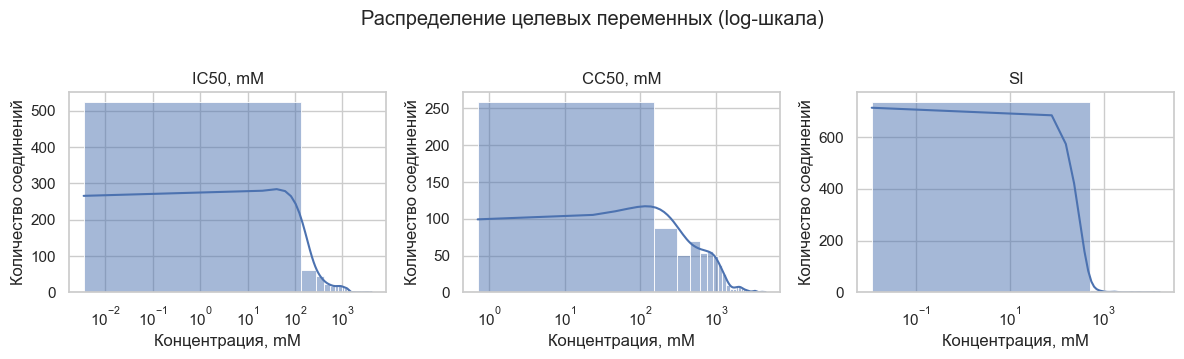

In [183]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, TARGET_COLS):
    sns.histplot(train[col], bins=30, kde=True, ax=ax, color="#4c72b0")
    ax.set_title(col)
    ax.set_xlabel("Концентрация, mM")
    ax.set_ylabel("Количество соединений")
    ax.set_xscale("log")
plt.suptitle("Распределение целевых переменных (log-шкала)", y=1.02)
plt.tight_layout()
plt.show()


### 8.3 Проверка признаков


In [184]:
raw_train = pd.read_csv(DATA_DIR / "train.csv")
raw_cols = [c for c in raw_train.columns if c not in [ID_COL, *TARGET_COLS]]
const_cols = [c for c in raw_cols if raw_train[c].nunique(dropna=False) <= 1]
print(f"Признаков до фильтра: {len(raw_cols)} → после: {X_train.shape[1]}")
print(f"Константных удалено: {len(const_cols)}")
print("Примеры константных:", const_cols[:5])

feat_na = X_train.isna().sum()
print("Колонок с NaN:", int((feat_na > 0).sum()), "| max NaN:", int(feat_na.max()))


Признаков до фильтра: 210 → после: 192
Константных удалено: 18
Примеры константных: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH']
Колонок с NaN: 12 | max NaN: 2


### 8.4 Обучение и OOF


Время выполнения: **~7–8 мин на CPU** (2 seed).

In [185]:
%%time
check_external_files(BEST_CFG)
ext = load_ext_cols(feature_cols)
blocks = feature_blocks(feature_cols)
X_ext, y_ext = load_external_ic50(IC50_EXTERNAL, train_cols=feature_cols)

clear_fold_cache()
oof_final, _ = fit_pipeline(
    X_train, X_test, y_train, ext, blocks, RANDOM_STATE, X_ext, y_ext, BEST_CFG,
)
test_final = predict_test(
    BEST_CFG, cols=feature_cols, X=X_train, Xt=X_test, y=y_train,
    ext=ext, blocks=blocks, seed=RANDOM_STATE,
)
oof_score = competition_score(y_train, oof_final)
oof_rmse = per_target_rmse(y_train, oof_final)
print(f"OOF — средний RMSE: {oof_score:.2f}")
print("RMSE по таргетам:", dict(zip(SUBMISSION_COLS, [round(x, 2) for x in oof_rmse])))


/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/chemAI-5-iishnitca/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/chemAI-5-iishnitca/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/chemAI-5-iishnitca/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/chemAI-5-iishnitca/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/chemAI-5-iishnitca/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow

OOF — средний RMSE: 525.28
RMSE по таргетам: {'IC50': 324.0, 'CC50': 463.38, 'SI': 788.45}
CPU times: user 15min 59s, sys: 5min 25s, total: 21min 24s
Wall time: 2min 45s


### 8.5 Формирование сабмита


In [186]:
submission = sample_submission.copy()
submission[SUBMISSION_COLS] = np.clip(test_final, 0, None)
submission.to_csv(OUTPUT_PATH, index=False)
print(f"Сохранено: {OUTPUT_PATH}")
submission.head()


Сохранено: /Users/dmitriytonkusin/Mephi/Машинное обучение без учителя/chemAI-5-iishnitca/submission.csv


,index,IC50,CC50,SI
0,0,173.822490,179.146894,2.432463
1,1,210.741502,320.152114,2.650975
2,2,49.552313,286.786571,6.174819
3,3,343.962514,525.656516,2.845905
4,4,191.359610,207.811042,1.563890


**Этапы разработки финального пайплайна:**
1. Базовый ансамбль: кластеризация + трансдуктивный kNN для CC50 (~306 RMSE на старте).
2. Разностные признаки IC50 и structural CatBoost (fr, mordred, morgan) — Phase H.
3. Фильтр ChEMBL + калиброванный kNN-признак (Phase X3, Y).
4. Два kNN по IC50: калиброванный pIC50 и сырой медианный (k=4, Phase AD/AF).
5. kNN для CC50 (k=6) + усреднение test по seed 42 и 7.
